In [57]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import matplotlib.pyplot as plt
import option_chain_generator as oc
import numpy as np

# Option Data Generation

In [108]:
mat_days= (np.arange(7, 365, 10))

df = oc.make_synth_iv_chain(seed = 12, maturities_days=mat_days, n_k=15, k_min=-0.1, k_max=0.1)

In [109]:
df.head()

,T,T_days,K,OptionType,iv_mid,iv_bid,iv_ask,F,S0,r,q
0,0.019178,7,90.518455,C,0.453094,0.449094,0.457094,100.038364,100.0,0.02,0.0
1,0.019178,7,90.518455,P,0.453094,0.449094,0.457094,100.038364,100.0,0.02,0.0
2,0.019178,7,91.820856,C,0.426318,0.422746,0.429889,100.038364,100.0,0.02,0.0
3,0.019178,7,91.820856,P,0.426318,0.422746,0.429889,100.038364,100.0,0.02,0.0
4,0.019178,7,93.141997,C,0.386738,0.383595,0.389881,100.038364,100.0,0.02,0.0


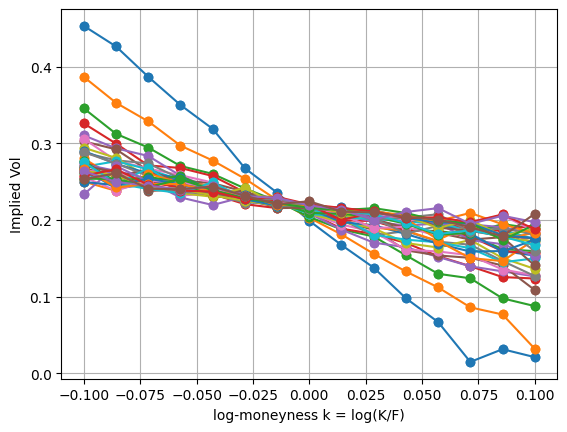

In [110]:
T_unique = df["T"].unique()

for T0 in T_unique:
    d = df[df["T"] == T0].copy()
    d["k"] = np.log(d["K"] / d["F"])

    plt.plot(d["k"], d["iv_mid"], marker="o", label=f"T={T0:.2f}")

plt.xlabel("log-moneyness k = log(K/F)")
plt.ylabel("Implied Vol")
#plt.legend()
plt.grid(True)
plt.show()


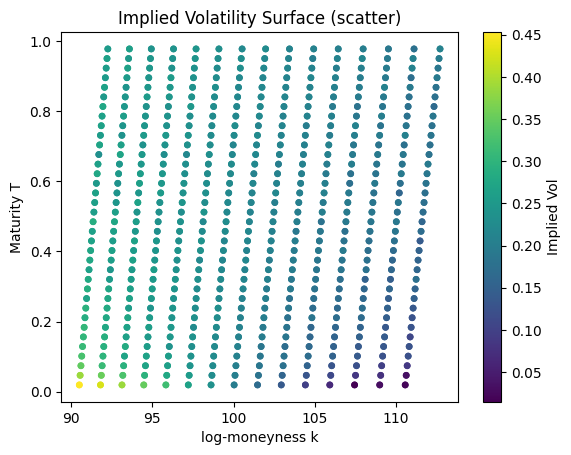

In [111]:
plt.scatter(
    df["K"],
    df["T"],
    c=df["iv_mid"],
    cmap="viridis",
    s=15
)
plt.colorbar(label="Implied Vol")
plt.xlabel("log-moneyness k")
plt.ylabel("Maturity T")
plt.title("Implied Volatility Surface (scatter)")
plt.show()


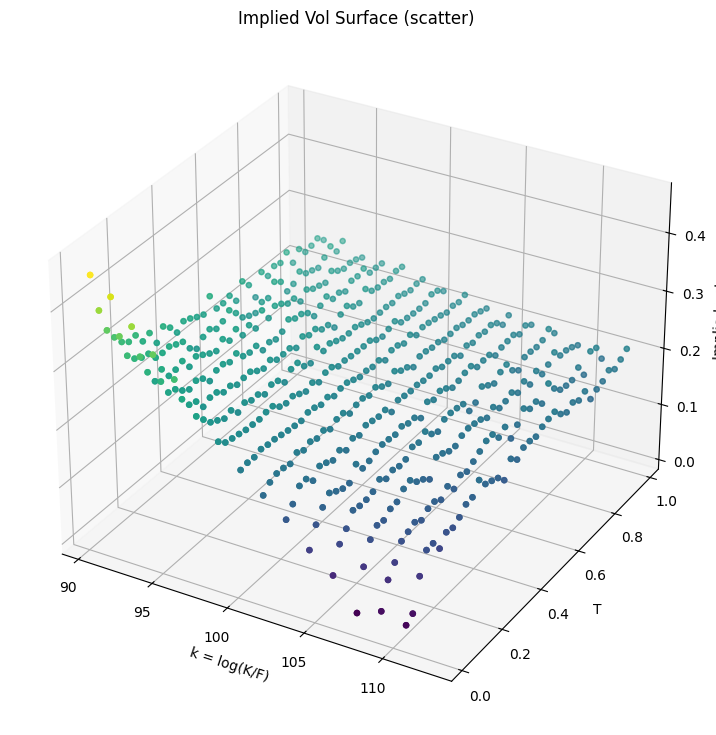

In [112]:

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(df["K"], df["T"], df["iv_mid"], s=14, c=df["iv_mid"], cmap = 'viridis')

ax.set_xlabel("k = log(K/F)")
ax.set_ylabel("T")
ax.set_zlabel("Implied vol")
ax.set_title("Implied Vol Surface (scatter)")
plt.show()

# SVI

In [113]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [325]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from svi import SVI, SVIParams
import option_chain_generator as oc

In [304]:
mat_days= np.arange(30, 720, 30)

df = oc.make_synth_iv_chain(seed = 12, n_k=15, maturities_days=mat_days, noise_wings=0.004, k_min=-0.2, k_max=0.2)

In [424]:
mat_days= np.arange(30, 720, 30)
df = oc.make_chain_from_local_vol(maturities_days=mat_days)

In [435]:
df = oc.true_local_vol(2, 0.2)

In [425]:
data = df

In [401]:
df = df[df["T_days"]>60]

In [436]:
df

0.20085572344733835

In [403]:
df

,T,T_days,K,OptionType,iv_mid,iv_bid,iv_ask,F,S0,r,q
84,0.246575,90,82.277830,C,0.196710,0.191710,0.201710,100.494369,100.0,0.02,0.0
85,0.246575,90,82.277830,P,0.196710,0.191710,0.201710,100.494369,100.0,0.02,0.0
86,0.246575,90,83.939953,C,0.199752,0.195152,0.204352,100.494369,100.0,0.02,0.0
87,0.246575,90,83.939953,P,0.199752,0.195152,0.204352,100.494369,100.0,0.02,0.0
88,0.246575,90,85.635652,C,0.201396,0.197196,0.205596,100.494369,100.0,0.02,0.0
...,...,...,...,...,...,...,...,...,...,...,...
961,1.890411,690,121.872864,P,0.178156,0.173956,0.182356,103.853204,100.0,0.02,0.0
962,1.890411,690,124.334859,C,0.177546,0.172946,0.182146,103.853204,100.0,0.02,0.0
963,1.890411,690,124.334859,P,0.177546,0.172946,0.182146,103.853204,100.0,0.02,0.0
964,1.890411,690,126.846590,C,0.176910,0.171910,0.181910,103.853204,100.0,0.02,0.0


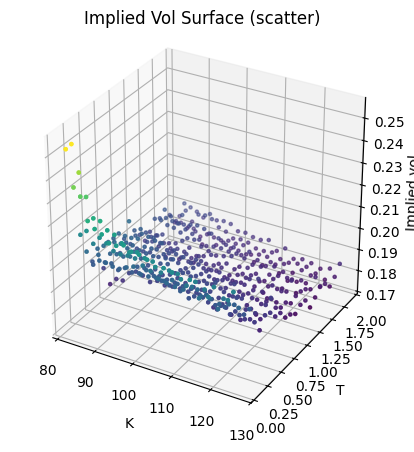

In [427]:
%matplotlib inline
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.set_box_aspect((1, 1, 1))  # allonge l’axe z

ax.scatter(df["K"], df["T"], df["iv_mid"], s=5, c=df["iv_mid"], cmap="viridis")
ax.set_xlabel("K")
ax.set_ylabel("T")
ax.set_zlabel("Implied vol")
ax.set_title("Implied Vol Surface (scatter)")
plt.show()


In [428]:

#computes total implied variance and log moneyness :
df["w"] = df["iv_mid"]**2 * df["T"]
df["log_moneyness"] = np.log(df["K"] / df["F"])

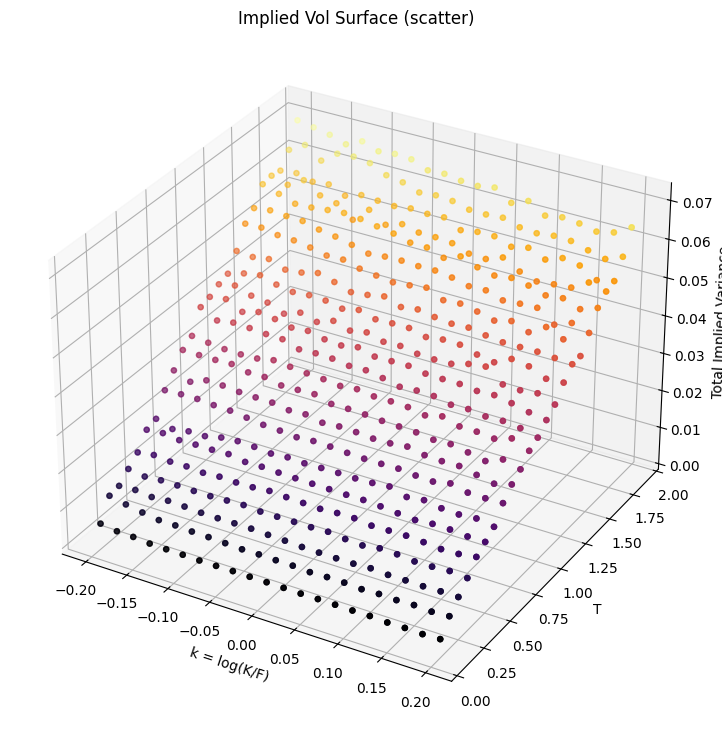

In [429]:

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(df["log_moneyness"], df["T"], df["w"], s=14, c=df["w"], cmap = 'inferno')

ax.set_xlabel("k = log(K/F)")
ax.set_ylabel("T")
ax.set_zlabel("Total Implied Variance")
ax.set_title("Implied Vol Surface (scatter)")
plt.show()

In [430]:
assert (df["w"] >= 0).all()
assert df["T"].min() > 0



In [431]:
opt = df["OptionType"].str.upper().str[0]   # "C" or "P"
is_call = opt == "C"
is_put  = opt == "P"

df = df[(is_call & (df["K"] >= df["F"])) | (is_put & (df["K"] <= df["F"]))]


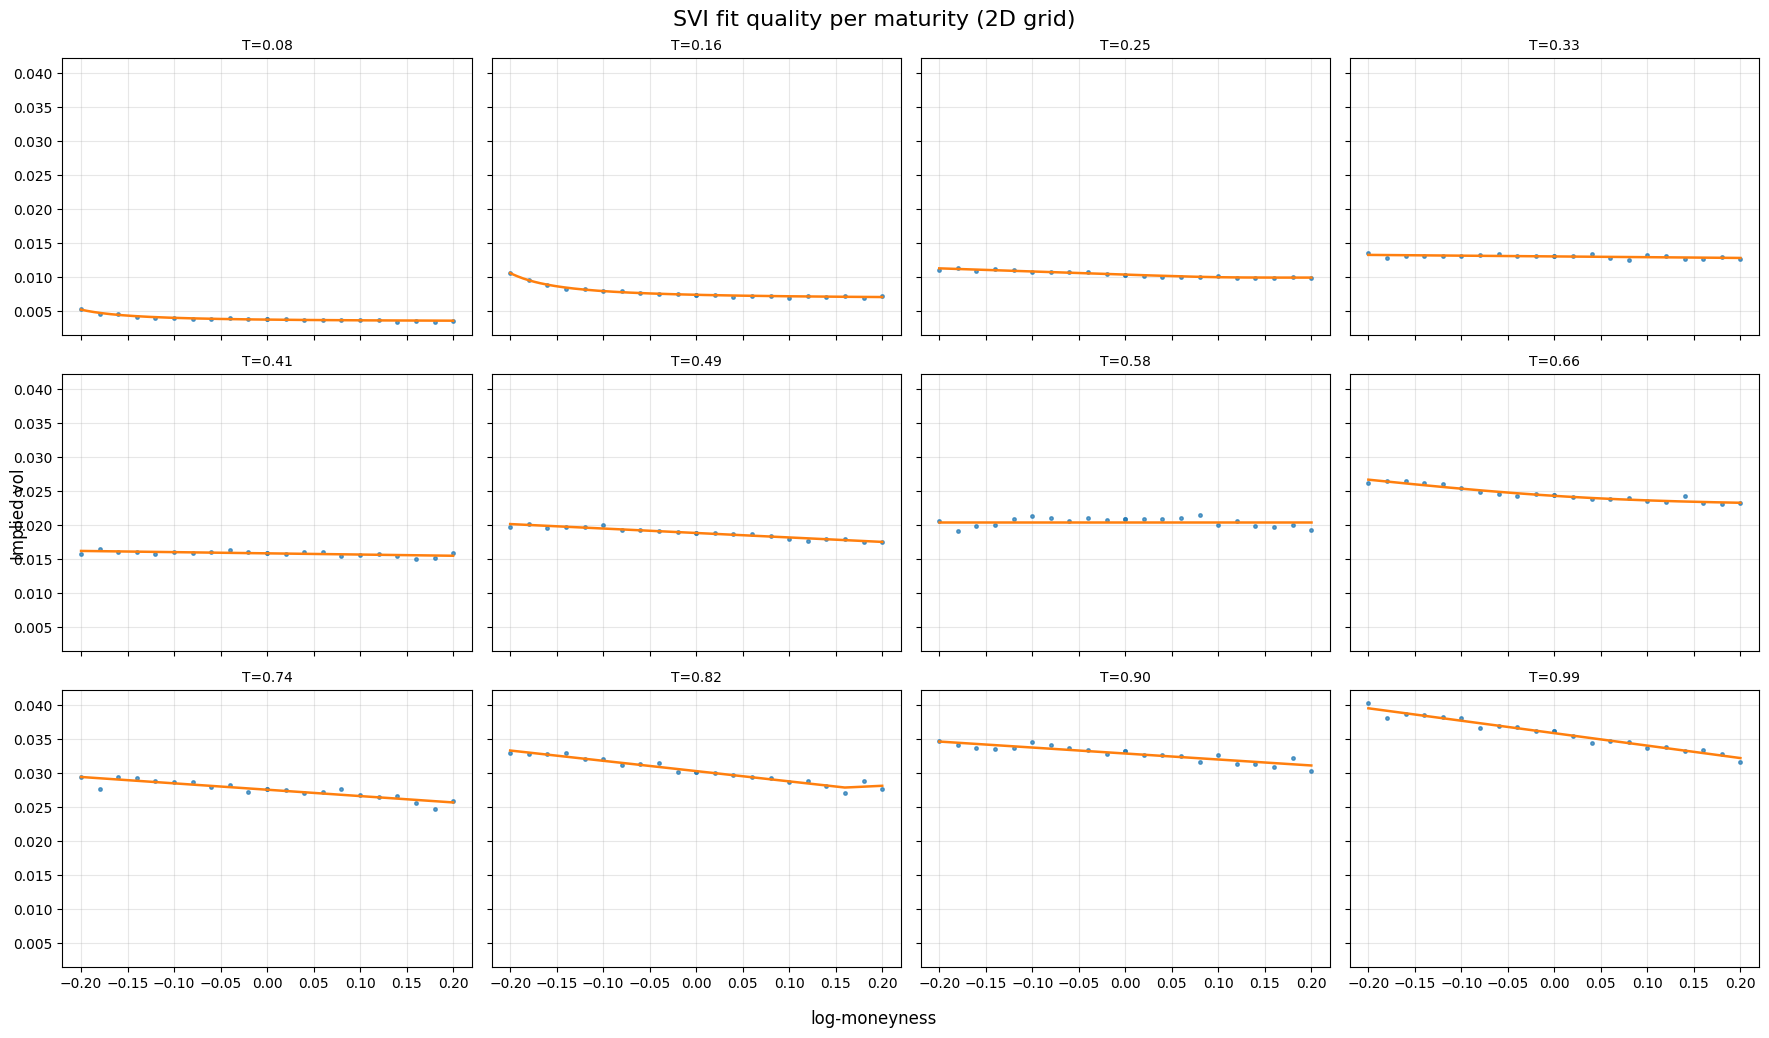

In [432]:

T_unique = np.sort(df["T"].unique())
n = len(T_unique[:12])
n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 3.5*n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(T_unique[:12]):
    ax = axes[i]
    sub = df[df["T"] == t]

    params = svi.fit(sub["log_moneyness"], sub["w"])
    lm = np.linspace(sub["log_moneyness"].min(), sub["log_moneyness"].max(), 200)

    w_fit = svi.compute(lm, params)
    iv_fit = np.sqrt(np.maximum(w_fit, 0.0) / t)

    ax.plot(sub["log_moneyness"], sub["w"], "o", markersize=2.5, alpha=0.7)
    ax.plot(lm, w_fit, "-", linewidth=1.8)


    ax.set_title(f"T={t:.2f}", fontsize=10)
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.supxlabel("log-moneyness")
fig.supylabel("Implied vol")
fig.suptitle("SVI fit quality per maturity (2D grid)", fontsize=16)
plt.tight_layout()
plt.show()



In [434]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["log_moneyness"],
    df["T"],
    df["w"],
    s=12,
    alpha=1,
    c=df["w"],
    cmap="inferno"
)

svi = SVI()
T_unique = np.sort(df["T"].unique())
params_by_T = {}

for t in T_unique:
    sub = df[df["T"] == t]

    # Fit SVI on total variance
    params = svi.fit(
        sub["log_moneyness"].to_numpy(),
        sub["w"].to_numpy()
    )
    params_by_T[t] = params

    # Grid in log-moneyness
    lm_grid = np.linspace(
        sub["log_moneyness"].min(),
        sub["log_moneyness"].max(),
        200
    )

    # SVI total variance
    w_fit = svi.compute(lm_grid, params)


    ax.plot(
        lm_grid,
        np.full_like(lm_grid, t),
        w_fit,
        linewidth=2, 
        linestyle = "--",
        color = "black",
        alpha = 0.4
    )

ax.set_xlabel("log-moneyness k = log(K/F)")
ax.set_ylabel("T")
ax.set_zlabel("Total implied variance w")
ax.set_title("Total implied variance surface: market + SVI fit")

plt.show()


RuntimeError: SVI fit failed: The maximum number of function evaluations is exceeded.

In [ ]:
import numpy as np
from scipy.interpolate import PchipInterpolator

# Suppose you already have:
# params_by_T: dict {T: SVIParams}
# svi.compute(k, params) -> w

T_grid = np.array(sorted(params_by_T.keys()), dtype=float)

# 1) choose a common log-moneyness grid
k_grid = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 201)

# 2) build W(T_i, k_j)
W = np.vstack([svi.compute(k_grid, params_by_T[T]) for T in T_grid])  # shape (nT, nk)

# 3) build interpolators in T for each k_j (PCHIP is shape-preserving)
interp_T = [PchipInterpolator(T_grid, W[:, j], extrapolate=False) for j in range(W.shape[1])]

def w_interp(log_moneyness, T):
    """Interpolate total variance w(log_moneyness, T) from fitted SVI smiles."""
    log_moneyness = float(log_moneyness); T = float(T)

    # evaluate w at this T on all log_moneyness_grid nodes
    w_on_log_moneyness_grid = np.array([f(T) for f in interp_T])  # shape (nlog_moneyness,)

    # interpolate in log_moneyness (1D linear is fine to start)
    return np.interp(log_moneyness, k_grid, w_on_log_moneyness_grid)


In [ ]:
log_moneyness_grid = np.linspace(-0.4, 0.4, 121)
T_grid_dense = np.linspace(T_grid.min(), T_grid.max(), 60)


In [ ]:
W_surface = np.zeros((len(T_grid_dense), len(log_moneyness_grid)))

for i, T in enumerate(T_grid_dense):
    for j, lm in enumerate(log_moneyness_grid):
        W_surface[i, j] = w_interp(lm, T)


In [ ]:
IV_surface = np.sqrt(
    np.maximum(W_surface, 0.0) / T_grid_dense[:, None]
)


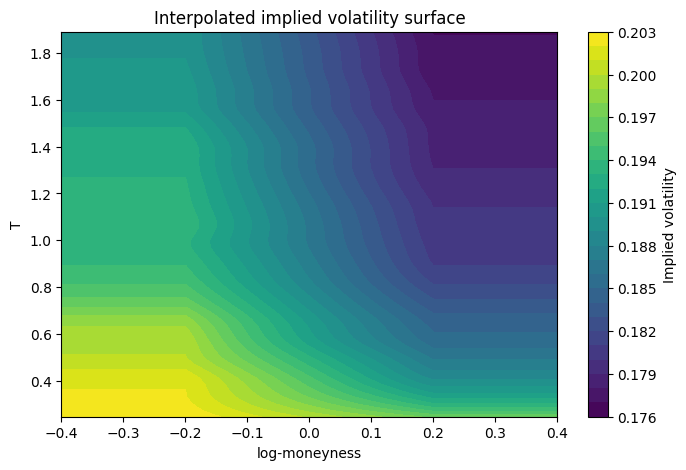

In [ ]:
import matplotlib.pyplot as plt

LM, TT = np.meshgrid(log_moneyness_grid, T_grid_dense)

plt.figure(figsize=(8, 5))
plt.contourf(LM, TT, IV_surface, levels=30, cmap="viridis")
plt.colorbar(label="Implied volatility")
plt.xlabel("log-moneyness")
plt.ylabel("T")
plt.title("Interpolated implied volatility surface")
plt.show()


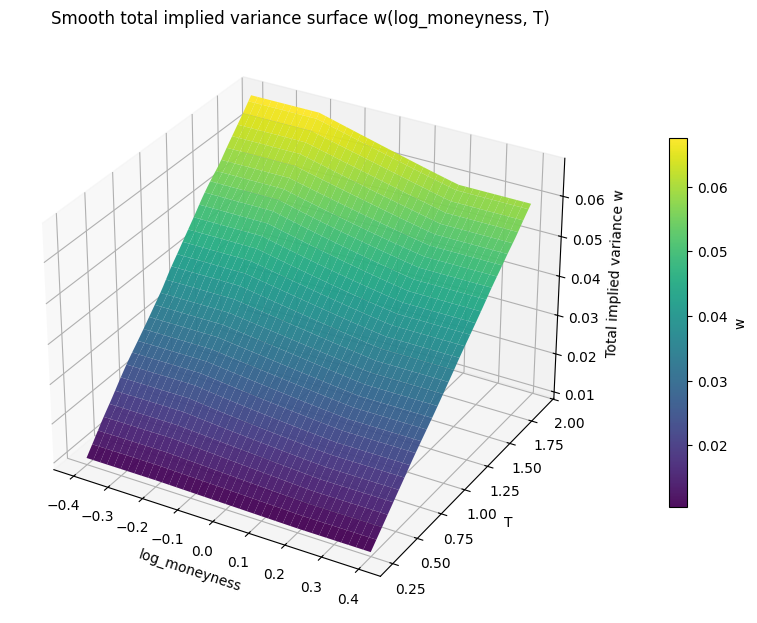

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grilles (reprends celles que tu utilises pour ta surface)
log_moneyness_grid = np.linspace(-0.4, 0.4, 121)
T_grid_dense = np.linspace(T_grid.min(), T_grid.max(), 60)

# Eval surface W(log_moneyness, T)
W_surface = np.zeros((len(T_grid_dense), len(log_moneyness_grid)))
for i, T in enumerate(T_grid_dense):
    for j, lm in enumerate(log_moneyness_grid):
        W_surface[i, j] = w_interp(lm, T)

# (optionnel) monotonie en T
W_surface = np.maximum.accumulate(W_surface, axis=0)

LM, TT = np.meshgrid(log_moneyness_grid, T_grid_dense)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(LM, TT, W_surface, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)

ax.set_xlabel("log_moneyness")
ax.set_ylabel("T")
ax.set_zlabel("Total implied variance w")
ax.set_title("Smooth total implied variance surface w(log_moneyness, T)")

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="w")
plt.show()


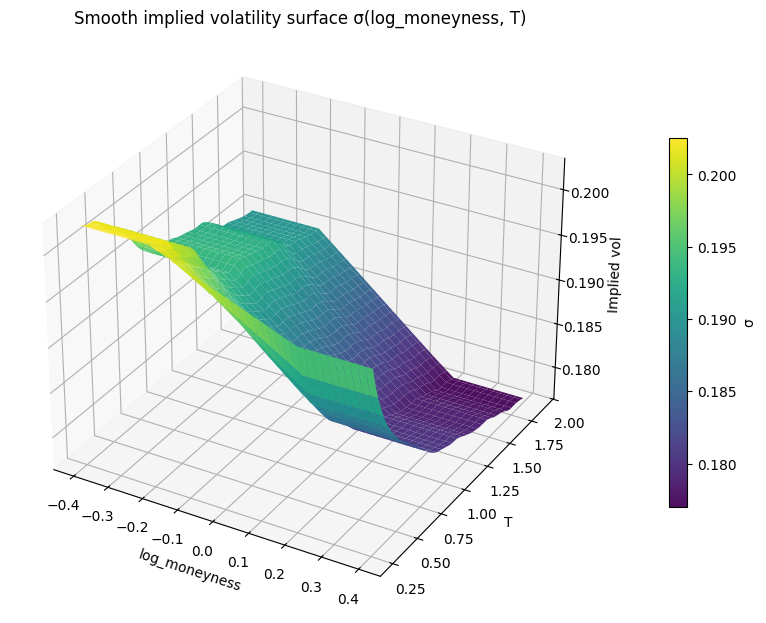

In [ ]:
IV_surface = np.sqrt(np.maximum(W_surface, 0.0) / T_grid_dense[:, None])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(LM, TT, IV_surface, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)

ax.set_xlabel("log_moneyness")
ax.set_ylabel("T")
ax.set_zlabel("Implied vol")
ax.set_title("Smooth implied volatility surface σ(log_moneyness, T)")

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="σ")
plt.show()


In [ ]:
import numpy as np
import plotly.graph_objects as go

# Grilles
log_moneyness_grid = np.linspace(-0.4, 0.4, 121)
T_grid_dense = np.linspace(T_grid.min(), T_grid.max(), 60)

# Eval surface W(log_moneyness, T)
W_surface = np.zeros((len(T_grid_dense), len(log_moneyness_grid)))
for i, T in enumerate(T_grid_dense):
    for j, lm in enumerate(log_moneyness_grid):
        W_surface[i, j] = w_interp(lm, T)

# (optionnel) forcer monotonie en T
W_surface = np.maximum.accumulate(W_surface, axis=0)

fig = go.Figure()

# Surface lisse
fig.add_surface(
    x=log_moneyness_grid,
    y=T_grid_dense,
    z=W_surface,
    colorscale="Viridis",
    opacity=0.95,
    colorbar=dict(title="Total variance w")
)

# (optionnel) Scatter marché
fig.add_scatter3d(
    x=df["log_moneyness"],
    y=df["T"],
    z=df["w"],
    mode="markers",
    marker=dict(size=2, opacity=0.3),
    name="Market data"
)

fig.update_layout(
    title="Total implied variance surface w(log_moneyness, T)",
    scene=dict(
        xaxis_title="log_moneyness",
        yaxis_title="T",
        zaxis_title="Total implied variance w",
    ),
    width=900,
    height=700,
)

fig.show()


In [ ]:
IV_surface = np.sqrt(np.maximum(W_surface, 0.0) / T_grid_dense[:, None])

fig = go.Figure()

fig.add_surface(
    x=log_moneyness_grid,
    y=T_grid_dense,
    z=IV_surface,
    colorscale="Viridis",
    opacity=0.95,
    colorbar=dict(title="Implied vol")
)

# (optionnel) Scatter marché
fig.add_scatter3d(
    x=df["log_moneyness"],
    y=df["T"],
    z=df["iv_mid"],
    mode="markers",
    marker=dict(size=2, opacity=0.3),
    name="Market data"
)

fig.update_layout(
    title="Implied volatility surface σ(log_moneyness, T)",
    scene=dict(
        xaxis_title="log_moneyness",
        yaxis_title="T",
        zaxis_title="Implied volatility",
    ),
    width=900,
    height=700,
)

fig.show()


In [437]:
T_grid = np.linspace(0.05, 2.0, 25)          # maturities (years)
lm_grid = np.linspace(-0.25, 0.25, 41)       # log-moneyness

LM, TT = np.meshgrid(lm_grid, T_grid)

# true local vol
sigma_true = oc.true_local_vol(TT, LM)

# total variance surface
W = sigma_true**2 * TT

In [440]:
import numpy as np

# --- Inputs ---
# T_grid_dense: (nT,)
# log_moneyness_grid: (nLM,)
# W_surface: (nT, nLM) = Theta(T, log_moneyness)

T = T_grid_dense
LM = log_moneyness_grid
Theta = W_surface.copy()

# (recommandé) éviter Theta=0 et petites valeurs -> stabilité num
eps = 1e-10
#Theta = np.maximum(Theta, eps)
Theta = W.copy()
T = T_grid


# ---------- Derivatives ----------
# dTheta/dT : dérivée en T (central diff)
dT_Theta = np.empty_like(Theta)
dT = np.diff(T)

# interior
dT_Theta[1:-1, :] = (Theta[2:, :] - Theta[:-2, :]) / (T[2:, None] - T[:-2, None])
# boundaries (one-sided)
dT_Theta[0, :] = (Theta[1, :] - Theta[0, :]) / (T[1] - T[0])
dT_Theta[-1, :] = (Theta[-1, :] - Theta[-2, :]) / (T[-1] - T[-2])

# dTheta/dLM and d2Theta/dLM2 : dérivées en log_moneyness
dLM_Theta = np.empty_like(Theta)
dLM2_Theta = np.empty_like(Theta)

# first derivative (central)
dLM_Theta[:, 1:-1] = (Theta[:, 2:] - Theta[:, :-2]) / (LM[2:] - LM[:-2])[None, :]
dLM_Theta[:, 0] = (Theta[:, 1] - Theta[:, 0]) / (LM[1] - LM[0])
dLM_Theta[:, -1] = (Theta[:, -1] - Theta[:, -2]) / (LM[-1] - LM[-2])

# second derivative (central)
h = LM[1] - LM[0]  # suppose grid quasi-uniforme; sinon on peut faire une version non-uniforme
dLM2_Theta[:, 1:-1] = (Theta[:, 2:] - 2 * Theta[:, 1:-1] + Theta[:, :-2]) / (h * h)
dLM2_Theta[:, 0] = dLM2_Theta[:, 1]
dLM2_Theta[:, -1] = dLM2_Theta[:, -2]

# ---------- Dupire (Gatheral form) ----------
KAPPA = LM[None, :]  # broadcast to (nT, nLM)
KAPPA = lm_grid

term1 = 1.0 - (KAPPA / Theta) * dLM_Theta
term2 = 0.25 * (-0.25 - 1.0 / Theta + (KAPPA * KAPPA) / (Theta * Theta)) * (dLM_Theta * dLM_Theta)
term3 = 0.5 * dLM2_Theta

denom = term1 + term2 + term3

# local variance and local vol
local_var = dT_Theta / denom

# nettoyage numérique (évite NaN/neg)
local_var = np.where(np.isfinite(local_var), local_var, np.nan)
local_var = np.maximum(local_var, 0.0)

local_vol = np.sqrt(local_var)


ValueError: operands could not be broadcast together with shapes (25,39) (1,119) 

In [439]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_surface(x=LM, y=T, z=local_vol, colorscale="Viridis", colorbar=dict(title="σ_loc"))
fig.update_layout(
    title="Dupire local volatility surface σ_loc(log_moneyness, T)",
    scene=dict(xaxis_title="log_moneyness", yaxis_title="T", zaxis_title="local vol"),
    width=900, height=700
)
fig.show()
